In [1]:
#Plots y comaparativa, antes de esto colocar toda la contextualización

import numpy as np
import matplotlib.pyplot as plt

import mhd_solver as solver

data = np.load(
    "orszag_snapshots.npz",
    allow_pickle=True
)

snapshots = data["snapshots"].item()

print(snapshots.keys())

dict_keys([0.1, 0.5, 1.0])


In [ ]:
#primitivas 

def get_primitives(snapshot):

    rho, mx, my, E, Bx, By = snapshot

    rho, vx, vy, P, Bx, By = solver.conserved_to_primitive(
        rho, mx, my, E, Bx, By
    )

    Vmag = np.sqrt(vx**2 + vy**2)
    Bmag = np.sqrt(Bx**2 + By**2)

    return rho, P, Vmag, Bmag

In [3]:
#Gráfica
def plot_variable(field, title):

    plt.figure(figsize=(7,6))

    plt.imshow(
        field,
        origin="lower",
        cmap="viridis"
    )

    plt.colorbar()

    plt.title(title)

    plt.tight_layout()

    plt.show()

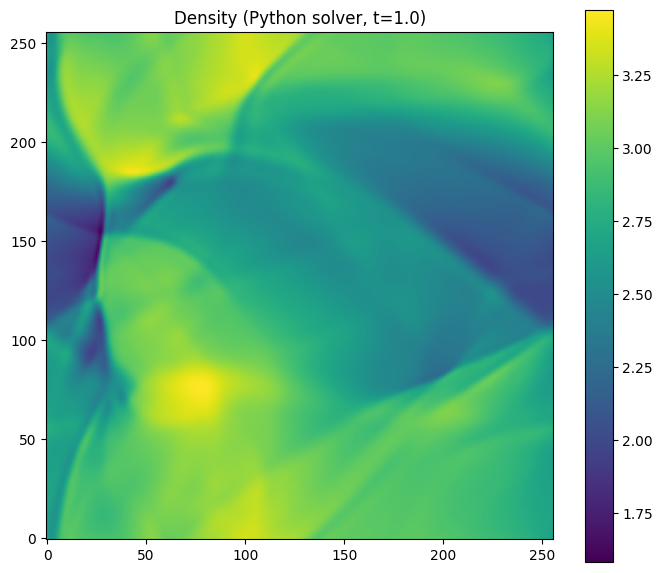

In [4]:
#Densidad en t=1
rho, P, Vmag, Bmag = get_primitives(
    snapshots[1.0]
)

plot_variable(
    rho,
    "Density (Python solver, t=1.0)"
)

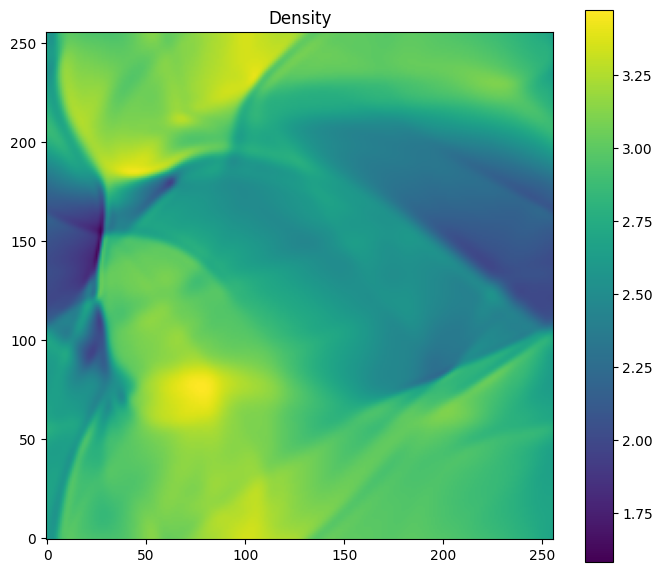

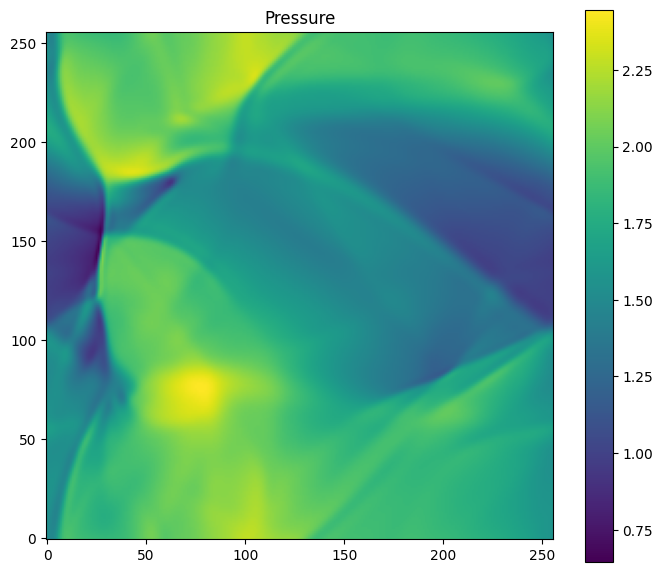

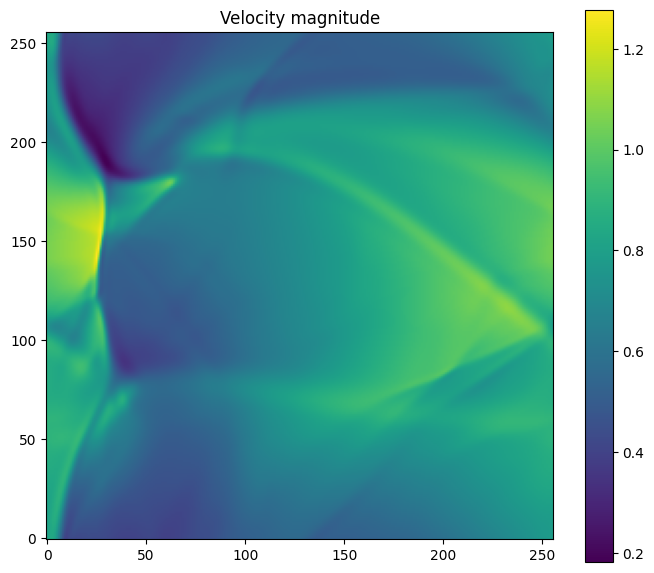

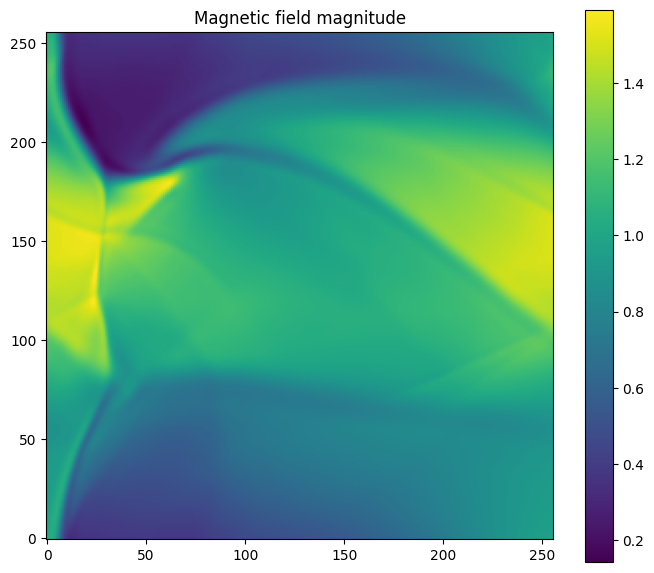

In [5]:
#Las 4 variables
rho, P, Vmag, Bmag = get_primitives(
    snapshots[1.0]
)

plot_variable(rho,  "Density")
plot_variable(P,    "Pressure")
plot_variable(Vmag, "Velocity magnitude")
plot_variable(Bmag, "Magnetic field magnitude")

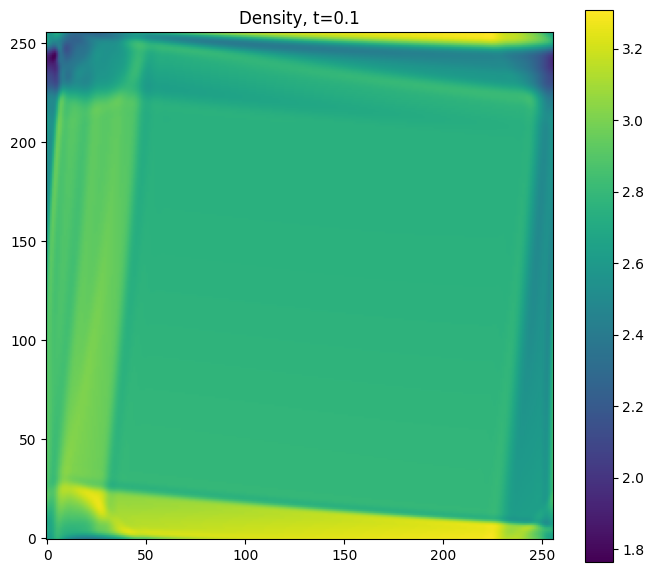

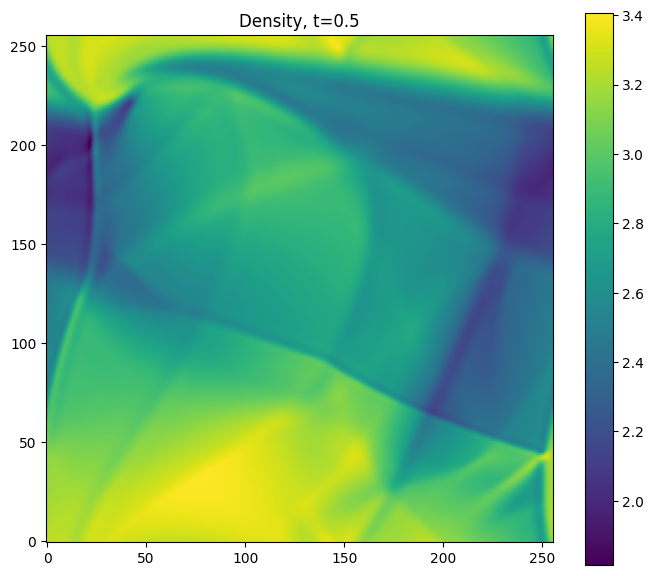

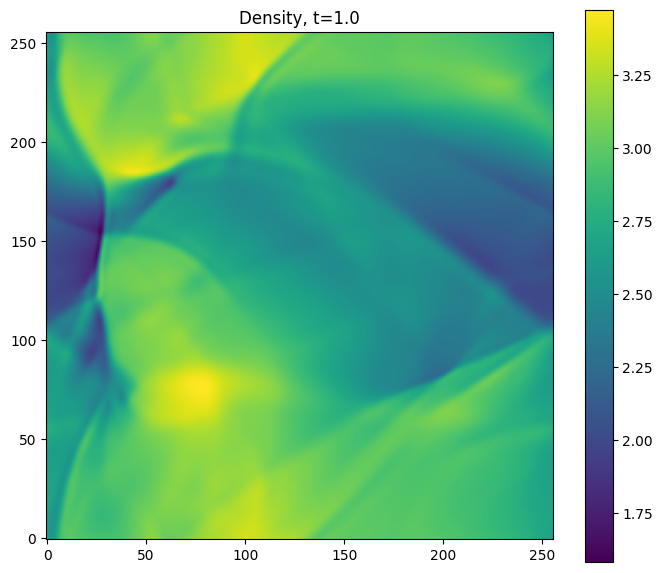

In [ ]:
#Evolución temporal, en principio este es solo para rho, debería repetirlo para P, Vmag, Bmag

times = [0.1, 0.5, 1.0]

for t in times:

    rho, P, Vmag, Bmag = get_primitives(
        snapshots[t]
    )

    plot_variable(
        rho,
        f"Density, t={t}"
    )